# 농약 구조 분포 분석 — 농약다움 점수 만들기

## 학습 목표
- PubChem 농약 데이터에서 **분자 구조 속성 5가지**의 분포를 살펴본다.
- 분포의 대표 구간(5%~95%)을 이용해 **농약다움 점수(agro_score)** 함수를 만든다.

## 기말고사 맥락
- 최종 목표: ZINC DB에서 **농약 분포에 가까운 신규 분자**를 찾아보기.
- 이번 시간엔 "분자가 얼마나 농약 같은지"를 **0~5점**으로 채점하는 함수를 만든다.
- 다음 시간엔 이 점수를 사용해 ZINC 분자들을 평가·선택한다.

## Tice rule (Tice, 2001)
농약(pesticide)이 가지는 전형적인 물리화학적 속성 5가지:

| 약자 | 풀이 | 의미 |
|---|---|---|
| **MW** | molecular weight | 분자량 |
| **logP** | octanol-water partition coefficient | 친지질성 (지방에 잘 녹는 정도) |
| **HBA** | hydrogen bond acceptor | 수소결합 받개 개수 |
| **HBD** | hydrogen bond donor | 수소결합 주개 개수 |
| **TPSA** | topological polar surface area | 분자의 극성 표면 넓이 |

이 5개 값이 농약 분포 안에 들어 있을수록 "농약다움"이 높다고 본다.

## 1. 데이터 불러오기

`PubChem_Agrochemical.csv` — PubChem에서 농약(Agrochemical)으로 분류된 화합물 목록.

In [1]:
import pandas as pd

# CSV 파일을 표(DataFrame)로 읽어들임
df = pd.read_csv('PubChem_Agrochemical.csv')

print('전체 행/열:', df.shape)         # (행 개수, 열 개수)
df[['cmpdname', 'mw', 'xlogp']].head(3)  # 처음 3개 화합물의 이름·MW·logP만 보기

# 예상 출력:
# 전체 행/열: (3098, 38)
# (cmpdname, mw, xlogp 칼럼이 있는 표 3행)

전체 행/열: (3098, 38)


,cmpdname,mw,xlogp
0,"1,2-Dichloroethane",98.96,1.5
1,Tartronic acid,120.06,-1.1
2,3-Hydroxybenzaldehyde,122.12,1.4


## 2. Tice rule — 5개 속성만 추출

CSV에는 38개 칼럼이 있지만, 우리는 Tice rule 5개와 화합물 이름만 사용한다.

| CSV 칼럼명 | 의미 |
|---|---|
| `mw` | MW (분자량) |
| `xlogp` | logP |
| `hbondacc` | HBA |
| `hbonddonor` | HBD |
| `polararea` | TPSA |

In [2]:
# 필요한 칼럼만 골라낸다
df = df[['cmpdname', 'mw', 'xlogp', 'hbondacc', 'hbonddonor', 'polararea']]

# 값이 비어 있는 행(NaN 포함)은 제거
df = df.dropna()

print('속성만 남긴 후 행/열:', df.shape)
df.head(3)

# 예상 출력:
# 속성만 남긴 후 행/열: (2686, 6)

속성만 남긴 후 행/열: (2686, 6)


,cmpdname,mw,xlogp,hbondacc,hbonddonor,polararea
0,"1,2-Dichloroethane",98.96,1.5,0,0,0.0
1,Tartronic acid,120.06,-1.1,5,3,94.8
2,3-Hydroxybenzaldehyde,122.12,1.4,2,1,37.3


## 3. 분포 통계 — 평균·표준편차·사분위수

`describe()` 한 줄로 5개 속성의 기본 통계를 한꺼번에 본다.
- `mean` = 평균
- `std` = 표준편차
- `25%`, `50%`, `75%` = 사분위수 (분포의 위치)

In [3]:
df.describe().round(2)

# 예상 출력 (요약):
# mw     평균 ≈ 300, 표준편차 ≈ 143
# xlogp  평균 ≈ 2.5
# hbondacc 평균 ≈ 4.7
# hbonddonor 평균 ≈ 1.2
# polararea 평균 ≈ 74

,mw,xlogp,hbondacc,hbonddonor,polararea
count,2686.00,2686.00,2686.00,2686.00,2686.00
mean,299.50,2.54,4.70,1.19,73.77
std,142.78,2.21,3.22,1.45,46.95
min,17.03,-21.40,0.00,0.00,0.00
25%,211.10,1.20,3.00,0.00,44.80
50%,284.11,2.60,4.00,1.00,66.40
75%,358.38,3.90,6.00,2.00,94.18
max,1526.50,22.40,47.00,29.00,808.00


## 4. 분포 시각화 — 히스토그램

숫자만 봐선 감이 안 오니 **히스토그램**(분포 그래프)으로 본다.

- 가로축: 속성 값
- 세로축: 그 값을 가지는 화합물 개수
- 봉우리(가운데가 가장 높은 곳)가 "전형적인 농약"의 위치

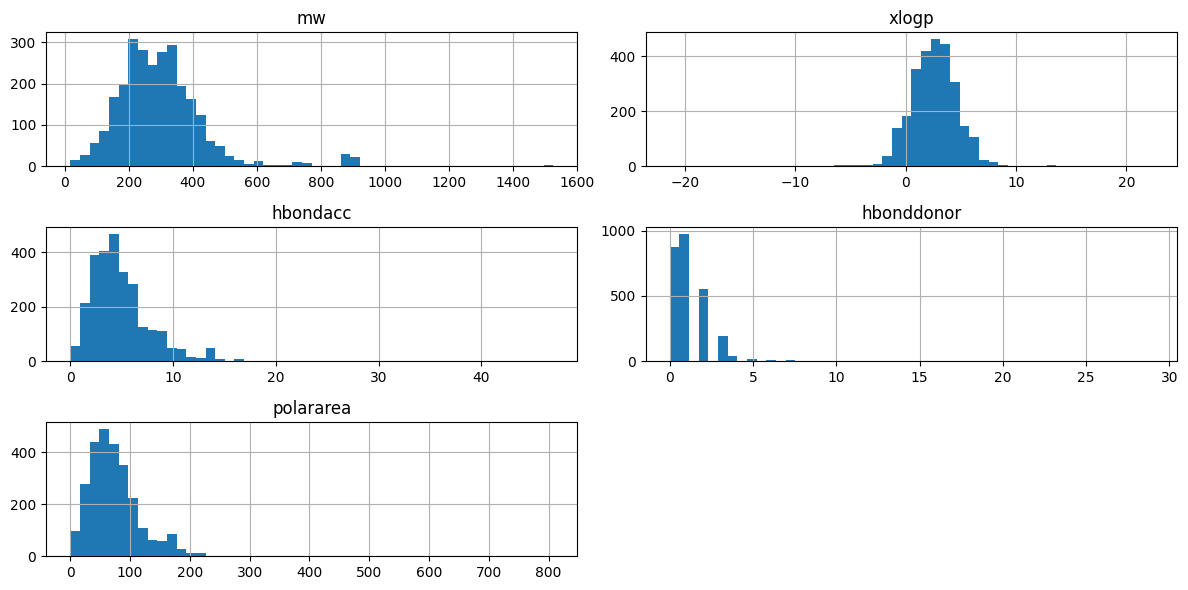

In [4]:
import matplotlib.pyplot as plt

# 5개 속성을 한꺼번에 히스토그램으로
df[['mw', 'xlogp', 'hbondacc', 'hbonddonor', 'polararea']].hist(bins=50, figsize=(12, 6))
plt.tight_layout()
plt.show()

# 예상 출력: 2x3 형태로 5개의 히스토그램이 나타난다
# - mw 봉우리: 약 200~400
# - xlogp 봉우리: 약 1~4
# - hbondacc 봉우리: 약 2~6
# - hbonddonor 봉우리: 약 0~2
# - polararea 봉우리: 약 40~100

## 5. 농약 분포의 대표 구간 — 5%~95%

각 속성에 대해 **하위 5% 값**과 **상위 95% 값**을 "농약의 대표 구간"으로 정한다.

- 즉, 농약 데이터의 **가운데 90%**가 들어 있는 구간
- 너무 극단적인 5%(아주 작은/아주 큰 값)는 제외 → 잡음 제거
- `quantile(0.05)` = 하위 5% 값, `quantile(0.95)` = 상위 95% 값

결과는 `ranges`라는 사전(dict)에 저장 → 이후 점수 함수에서 꺼내 쓴다.

In [5]:
ranges = {}    # (속성 이름) → (low, high) 쌍을 저장하는 사전

for col in ['mw', 'xlogp', 'hbondacc', 'hbonddonor', 'polararea']:
    low = df[col].quantile(0.05)     # 하위 5% 값
    high = df[col].quantile(0.95)    # 상위 95% 값
    ranges[col] = (round(low, 2), round(high, 2))

for col, (low, high) in ranges.items():
    print(f'{col:12s}: {low:7.2f} ~ {high:7.2f}')

# 예상 출력:
# mw          :  122.09 ~  505.00
# xlogp       :   -0.70 ~    6.00
# hbondacc    :    1.00 ~   11.00
# hbonddonor  :    0.00 ~    3.00
# polararea   :   20.20 ~  166.75

mw          :  122.09 ~  505.00
xlogp       :   -0.70 ~    6.00
hbondacc    :    1.00 ~   11.00
hbonddonor  :    0.00 ~    3.00
polararea   :   20.20 ~  166.75


## 6. 점수 함수 — 1개 속성으로 먼저 (예시)

감을 잡기 위해 **MW 한 개만** 보는 단순 점수부터 만들어 본다.

- 입력 MW가 농약의 5%~95% 구간 안에 있으면 → **1점**
- 밖에 있으면 → **0점**

In [6]:
def mw_score(mw):
    low, high = ranges['mw']         # 5단계에서 만들어둔 범위 꺼내기
    if low <= mw <= high:            # 범위 안이면 1점
        return 1
    return 0                         # 밖이면 0점


print('MW=300  →', mw_score(300))    # 농약 분포 안 → 1
print('MW=1000 →', mw_score(1000))   # 너무 큼 → 0

# 예상 출력:
# MW=300  → 1
# MW=1000 → 0

MW=300  → 1
MW=1000 → 0


## 7. 점수 함수 — 5개 속성 모두 (실습)

이제 5개 속성을 모두 본다.

**규칙**
- 5개 속성 각각이 농약 분포 5%~95% 구간 안에 있으면 1점씩
- 점수는 **0~5점**
- 5점 = 모든 속성이 전형적인 농약 분포 안에 있음 → "매우 농약 같다"

아래 함수의 `_____` 부분을 채워 완성하세요.

In [7]:
def agro_score(mw, logp, hba, hbd, tpsa):
    # 입력값 5개를 칼럼 이름과 짝지어 사전으로 묶어두면 반복문에서 다루기 편하다
    values = {
        'mw': mw,
        'xlogp': logp,
        'hbondacc': hba,
        'hbonddonor': hbd,
        'polararea': tpsa,
    }

    score = 0    # 점수를 0에서 시작

    # 5개 속성을 하나씩 꺼내서 검사
    for col, v in values.items():
        low, high = ranges[col]      # 그 속성의 농약 분포 범위

        # TODO 1: v가 low 이상이고 high 이하이면 (= 범위 안에 있으면)
        if _____:
            # TODO 2: score를 1 증가
            score = _____

    return score


# 테스트 — TODO 다 채운 뒤 실행
print('전형적 농약 (MW=300, logP=2.5, HBA=4, HBD=1, TPSA=70):',
      agro_score(300, 2.5, 4, 1, 70))

print('극단적 분자 (MW=1000, logP=12, HBA=30, HBD=20, TPSA=500):',
      agro_score(1000, 12, 30, 20, 500))

# 예상 출력 (TODO를 올바르게 채웠을 때):
# 전형적 농약 ... : 5
# 극단적 분자 ... : 0

NameError: name '_____' is not defined

## 8. 알려진 분자에 점수 매겨보기

실제 분자의 속성값을 직접 넣어 점수를 비교한다.

| 분자 | 종류 | MW | logP | HBA | HBD | TPSA |
|---|---|---|---|---|---|---|
| 아트라진 (Atrazine) | 제초제 | 215.7 | 2.6 | 5 | 2 | 62.7 |
| 카페인 (Caffeine) | 자극제 | 194.2 | -0.07 | 3 | 0 | 58.4 |
| 콜레스테롤 (Cholesterol) | 지질 | 386.7 | 8.7 | 1 | 1 | 20.2 |
| 수크로스 (Sucrose, 설탕) | 당 | 342.3 | -3.7 | 11 | 8 | 189.5 |

In [ ]:
print('아트라진(제초제) :', agro_score(215.7, 2.6, 5, 2, 62.7))
print('카페인          :', agro_score(194.2, -0.07, 3, 0, 58.4))
print('콜레스테롤       :', agro_score(386.7, 8.7, 1, 1, 20.2))
print('수크로스(설탕)   :', agro_score(342.3, -3.7, 11, 8, 189.5))

# 예상 출력:
# 아트라진(제초제) : 5    ← 모든 속성이 농약 분포 안 (당연)
# 카페인          : 5    ← 카페인도 우연히 농약과 비슷한 물성 영역에 있다
# 콜레스테롤       : 4    ← logP가 너무 큼 (지질이라 친지질성이 매우 강함)
# 수크로스(설탕)   : 2    ← logP/HBD/HBA가 모두 농약 범위 밖 (너무 극성, 너무 큰 당류)

# 해석: 점수가 높을수록 농약과 분자 물성이 비슷하다.
#       카페인이 5점인 것은 "농약이다"라는 뜻이 아니라
#       "분자 크기·극성·지질친화성이 농약과 비슷한 영역에 있다"는 뜻.

## 9. SMILES → 점수 (실제 활용)

기말고사에서는 ZINC DB의 SMILES만 주어진다 → 속성을 직접 계산해야 한다.

**RDKit**으로 SMILES 한 줄에서 5개 속성을 모두 계산할 수 있다.

| 속성 | RDKit 함수 |
|---|---|
| MW | `Descriptors.MolWt(mol)` |
| logP | `Crippen.MolLogP(mol)` |
| HBA | `Descriptors.NumHAcceptors(mol)` |
| HBD | `Descriptors.NumHDonors(mol)` |
| TPSA | `Descriptors.TPSA(mol)` |

In [ ]:
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, Crippen
RDLogger.DisableLog('rdApp.*')    # 경고 메시지 끄기


def smiles_to_score(smi):
    mol = Chem.MolFromSmiles(smi)             # SMILES 문자열 → 분자 객체
    return agro_score(
        mw=Descriptors.MolWt(mol),
        logp=Crippen.MolLogP(mol),
        hba=Descriptors.NumHAcceptors(mol),
        hbd=Descriptors.NumHDonors(mol),
        tpsa=Descriptors.TPSA(mol),
    )


# 다양한 분자에 적용
tests = [
    ('글리포세이트(제초제)', 'OC(=O)CNCP(=O)(O)O'),
    ('아트라진(제초제)   ', 'CCNc1nc(Cl)nc(NC(C)C)n1'),
    ('카페인             ', 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'),
    ('이부프로펜          ', 'CC(C)Cc1ccc(cc1)C(C)C(=O)O'),
    ('콜레스테롤          ', 'CC(C)CCCC(C)C1CCC2C1(CCC3C2CC=C4C3(CCC(C4)O)C)C'),
]

for name, smi in tests:
    print(f'{name}: {smiles_to_score(smi)}')

# 예상 출력:
# 글리포세이트(제초제): 3      (logP, HBD가 농약 범위 밖)
# 아트라진(제초제)   : 5      (모든 속성 통과)
# 카페인             : 4
# 이부프로펜          : 5      (모든 속성 통과)
# 콜레스테롤          : 4      (logP가 너무 큼)

## 10. QED 스타일 점수 — 연속 + 가중 기하평균

지금까지의 `agro_score`는 0/1을 합한 **0~5 정수**다. 두 가지 한계:

1. **경계가 칼 같다** — MW가 504면 1점, 506이면 0점. 비슷한 값이 갑자기 달라진다.
2. **한 항목이 망해도 만회 가능** — logP가 농약 범위를 한참 벗어나도 다른 4개가 통과면 4점.

**QED**(Quantitative Estimate of Drug-likeness, Bickerton et al. 2012)는 약물다움을 평가할 때 두 문제를 동시에 푼다. 같은 아이디어를 농약에 적용한다.

| 항목 | `agro_score` | QED 스타일 (`agro_qed`) |
|---|---|---|
| 속성당 출력 | 0 또는 1 | 0~1 **연속** (가우시안) |
| 결합 방식 | 산술합 | **가중 기하평균** (한 항목 망하면 전체 망함) |
| 속성별 중요도 | 모두 동일 | **가중치(0~1)로 조절 가능** |
| 최종 점수 | 0~5 정수 | 0~1 실수 |

### 1단계 — 가우시안 desirability

각 속성에 대해 **평균 μ에서 1, 멀어질수록 부드럽게 감소**:

```
d(x) = exp( -((x - μ)/σ)² / 2 )
```

- μ = 농약 데이터의 평균, σ = 표준편차

### 2단계 — 5개를 가중 기하평균으로 합치기

```
agro_qed = ( d_MW^w_MW × d_logP^w_logP × ... × d_TPSA^w_TPSA )^( 1 / (w_MW + ... + w_TPSA) )
```

- 가중치 wᵢ는 **0~1 사이의 실수**
  - **1.0** = 그 속성을 완전히 반영
  - **0.5** = 절반만 반영 (페널티 약해짐)
  - **0.0** = 그 속성 무시 (`d^0 = 1`이라 점수에 영향 없음)
- 가중치 합으로 정규화하기 때문에 **상대 비율**이 결과를 결정 → 모두 같은 값이면 균일 기하평균과 동일

### 왜 가중 기하평균인가 — 한 항목이 망했을 때

| desirability 5개 | 산술평균 | 기하평균 |
|---|---|---|
| 모두 0.9 | 0.90 | 0.90 |
| 4개 0.9, 1개 **0.01** | 0.72 | **0.36** |
| 4개 0.9, 1개 **0.0001** | 0.72 | **0.13** |

→ 한 속성이라도 농약 분포에서 크게 벗어나면 **기하평균은 강하게 깎이지만 산술평균은 거의 안 깎인다** = "농약다움은 5개 모두 적당해야 한다"는 의도를 살림.

In [ ]:
import math

# 5개 속성의 평균(μ)과 표준편차(σ)를 미리 저장 (3단계 describe()와 같은 값)
stats = {}
for col in ['mw', 'xlogp', 'hbondacc', 'hbonddonor', 'polararea']:
    stats[col] = (df[col].mean(), df[col].std())


def desirability(x, mu, sigma):
    """평균 mu에서 1, 멀어질수록 부드럽게 0으로 감소 (가우시안)"""
    return math.exp(-((x - mu) / sigma) ** 2 / 2)


def agro_qed(mw, logp, hba, hbd, tpsa, weights):
    """가중 기하평균. weights[col]은 0~1 사이 (1=완전 반영, 0=무시)."""
    values = {'mw': mw, 'xlogp': logp, 'hbondacc': hba,
              'hbonddonor': hbd, 'polararea': tpsa}

    product = 1.0
    total_w = 0.0
    for col, v in values.items():
        mu, sigma = stats[col]
        d = desirability(v, mu, sigma)
        w = weights[col]                       # 0 ≤ w ≤ 1
        product = product * (d ** w)           # weight 만큼만 영향
        total_w = total_w + w

    return product ** (1.0 / total_w)          # 가중치 합으로 정규화


def smiles_to_qed(smi, weights):
    mol = Chem.MolFromSmiles(smi)
    return agro_qed(
        mw=Descriptors.MolWt(mol),
        logp=Crippen.MolLogP(mol),
        hba=Descriptors.NumHAcceptors(mol),
        hbd=Descriptors.NumHDonors(mol),
        tpsa=Descriptors.TPSA(mol),
        weights=weights,
    )


# === 균일 가중치 — 5개 속성 모두 똑같이 반영 (시작값) ===
weights = {
    'mw':         1.0,
    'xlogp':      1.0,
    'hbondacc':   1.0,
    'hbonddonor': 1.0,
    'polararea':  1.0,
}

print(f'{"분자":<22}  agro_score   QED-style')
print('-' * 50)
for name, smi in tests:
    s1 = smiles_to_score(smi)
    s2 = smiles_to_qed(smi, weights)
    print(f'{name:<22}    {s1}/5       {s2:.3f}')

# 예상 출력 (모두 weight=1.0):
# 글리포세이트(제초제)        3/5       0.438
# 아트라진(제초제)           5/5       0.919
# 카페인                    4/5       0.658
# 이부프로펜                 5/5       0.785
# 콜레스테롤                 4/5       0.457
#
# === 직접 실험 — 위 weights 사전의 숫자(0~1)를 바꿔가며 점수 변화를 관찰 ===
# 예) 'xlogp': 0.5 로 바꾸면 → logP 페널티 절반 → 콜레스테롤 0.457 → 0.548 ↑
#     'xlogp': 0.0 로 바꾸면 → logP 무시      → 콜레스테롤 0.457 → 0.686 ↑↑
#     'mw'   : 0.5 로 바꾸면 → 분자량 영향 절반
# 어떤 속성이 농약다움을 가장 잘 분별하는지 학생이 직접 찾아보세요.

## 정리

- **Tice rule** = 농약을 정의하는 5가지 분자 속성: MW, logP, HBA, HBD, TPSA
- 농약 데이터의 **5%~95% 구간** → `agro_score(...)` → **0~5 정수**
- 평균·표준편차 + 가우시안 + **가중 기하평균** → `agro_qed(..., weights)` → **0~1 실수** (QED 스타일)
- 가중치 `weights[col]` 는 **0~1 사이 실수**로 속성별 중요도를 조절
- `smiles_to_score(smi)`, `smiles_to_qed(smi, weights)` → SMILES에서 직접 점수 계산

## 다음 시간 예고 — 점수 검증

이번에 만든 점수 함수가 **정말 농약과 비농약을 잘 구별하는지** 확인할 차례:

1. **ZINC DB**에서 농약과 닮지 않은 분자(약물·일반 화합물)를 추출
2. 추출한 분자들에 `agro_score`/`agro_qed`를 적용 → 점수 분포 확인
3. PubChem 농약 분포와 비교 → 우리 점수가 두 그룹을 잘 분리하는지 평가
4. **잘 분리되면** → 신규 분자 평가 도구로 사용 가능
5. **분리가 약하면** → `weights` 조정·임계값 튜닝으로 보강

## 기말고사 로드맵

1. **이번 시간**: 농약다움 점수 함수 두 종류 만들기 (`agro_score`, `agro_qed`) ✅
2. 다음 시간: ZINC 비농약 분자로 score **검증** + 가중치 튜닝
3. 그 다음: 후보 분자를 **변형**(원자 치환·추가, 9~10주차 알고리즘 활용)해 점수가 더 높은 신규 분자 만들기
4. 최종: 농약 분포에 맞는 **신규 물질 후보 제출**

## 추가 실험 과제 (선택)

1. **임계값 바꿔보기** — `agro_score`의 5%~95%를 10%~90%로 좁히면 어떻게 달라지는가?
2. **가중치 탐색** — `weights`의 5개 값(0~1)을 다양하게 바꾸며 알려진 분자들의 점수 변화를 표로 정리해 보자. 어떤 속성이 농약다움을 가장 잘 분별하는가?
3. **σ 조정** — 농약 분포는 약간 비대칭이다. 표준편차 σ 대신 (95% 값 − 평균)/2 를 위쪽 σ, (평균 − 5% 값)/2 를 아래쪽 σ로 써서 비대칭 가우시안으로 만들어 보자.